# **E-Commerce Company's Path to Sustainable Growth**
# End-to-End Exploratory Data Analysis (E2E EDA)

**Dataset:** Amazon / E-commerce Sales Dataset  
**Objective:** Use data-driven analysis to understand financial performance, customer behavior, logistics & fulfillment, product/inventory performance, and cancellations/returns.

##  `Problem Statement`
The e-commerce company is facing operational challenges that affect growth and customer satisfaction. The analysis aims to generate actionable insights for sustainable growth.
### Business objectives
Financial performance: revenue trend, best-selling products/categories, seasonal sales patterns, and average order value.  
Customer insights: top-performing locations, cancellations, and B2B vs B2C behavior.  
Logistics & fulfillment: compare Amazon vs Merchant fulfillment and shipping-service performance.  
Product & inventory: identify high-demand categories and average quantity ordered.  
Customer satisfaction & returns: investigate cancellation/return patterns and problematic products/categories.


### Analysis flow
1. Data Understanding
2. Data Cleaning & Validation
3. Feature Engineering
4. Financial Performance
5. Customer Insights
6. Logistics & Fulfillment
7. Product management and inventory
8. Customer satisfaction and returns
9. Business Questions and MCQs
10. Recommendations & Conclusion

### Important data limitations
1. The dataset has an order date but no separate shipped/delivered timestamps, so actual average shipping time cannot be calculated.
2. There is no customer ID, so true customer retention/repeat-customer rate cannot be measured.
3. Amount represents transaction/order value; it is not profit or margin.

## 1.  Data exploration and understanding.

In [ ]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the Dataset

url = "https://raw.githubusercontent.com/sonal-98/DA_Assignment_01/main/Dataset/sales_dataset.csv.gz"

df = pd.read_csv(
    url,
    compression="gzip",
    low_memory=False
)

print(df.shape)
df.head()

(128949, 23)


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# Displaying First 10 records

display(df.head(10))


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,...,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,XL,...,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,...,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,...,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,XXL,...,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN,NaN


In [ ]:
# Last 10 records

display(df.tail(10))

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
128939,408-5154281-4593912,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,J0119,J0119-TP-XXXL,Top,3XL,...,INR,574.0,Prayagraj (ALLAHABAD),UTTAR PRADESH,211007.0,IN,NaN,False,NaN,False
128940,406-9812666-2474761,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET224,SET224-KR-NP-XS,Set,XS,...,INR,1132.0,CHENNAI 600042,TAMIL NADU,600042.0,IN,NaN,False,NaN,False
128941,404-5182288-1653947,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,JNE3638,JNE3638-KR-XS,kurta,XS,...,NaN,NaN,Kolkata,WEST BENGAL,700040.0,IN,NaN,False,NaN,False
128942,403-7059995-7618722,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,...,INR,824.0,Delhi,DELHI,110053.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128943,404-3802633-7250760,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,SET044,SET044-KR-NP-M,Set,M,...,INR,612.0,MUMBAI,MAHARASHTRA,400017.0,IN,NaN,False,NaN,False
128944,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,...,INR,517.0,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128945,402-9551604-7544318,05-31-22,Cancelled,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,M,...,INR,999.0,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128946,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,...,INR,690.0,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,False
128947,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,XS,...,INR,1199.0,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128948,408-7436540-8728312,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0003,J0003-SET-S,Set,S,...,INR,696.0,Raipur,CHHATTISGARH,492014.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [ ]:
# Displays Rows and columns in dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])



Rows: 128949
Columns: 23


In [ ]:
# Column names

print(df.columns.tolist())


['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


In [ ]:
# Data types, memory usage, rows and columns informations and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [ ]:
# Statistical summary of all numerical as well as non-numerical columns

display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order ID,128949,120352,403-4984515-8861958,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,128949,91,05-03-2022,2085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,128949,13,Shipped,77767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfilment,128949,2,Amazon,89679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Channel,128949,2,Amazon.in,128825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship-service-level,128949,2,Expedited,88596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,128949,1377,JNE3797,4224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKU,128949,7195,JNE3797-KR-L,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,128949,9,Set,50275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,128949,11,M,22705,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Statistical summary of non-numerical columns

display(df.describe(include='object').T)

,count,unique,top,freq
Order ID,128949,120352,403-4984515-8861958,12
Date,128949,91,05-03-2022,2085
Status,128949,13,Shipped,77767
Fulfilment,128949,2,Amazon,89679
Sales Channel,128949,2,Amazon.in,128825
ship-service-level,128949,2,Expedited,88596
Style,128949,1377,JNE3797,4224
SKU,128949,7195,JNE3797-KR-L,773
Category,128949,9,Set,50275
Size,128949,11,M,22705


In [ ]:
# Statistical summary of numerical column

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Qty,128949.0,0.904629,0.314782,0.0,1.0,1.0,1.0,15.0
Amount,121155.0,648.550806,281.218324,0.0,449.0,605.0,788.0,5584.0
ship-postal-code,128916.0,463978.298008,191473.322953,110001.0,382421.0,500033.0,600024.0,989898.0


In [ ]:
# Checking frequency of Unique Values in each categorical columns

columns = [
    'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level',
    'Category', 'Size', 'Courier Status','ship-state', 'ship-postal-code', 'currency',
    'ship-country', 'fulfilled-by'
]

for col in columns:
  print(f"\n Name of the column:  {col} ")
  print(df[col].value_counts(dropna=True))


 Name of the column:  Status 
Status
Shipped                          77767
Shipped - Delivered to Buyer     28771
Cancelled                        18341
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

 Name of the column:  Fulfilment 
Fulfilment
Amazon      89679
Merchant    39270
Name: count, dtype: int64

 Name of the column:  Sales Channel  
Sales Channel 
Amazon.in     128825
Non-Amazon       124
Name: count, dtype: int64

 Name of the column:  ship-service-level 
ship-service-level
Expedited    88596
Standard     40353
Name: count, dtype: int64

 Name of the column:  Category 
Category
Set              50275
kurta   

## 2. Data Cleaning and Validation

### 2.1 Missing values
### 2.2 Remove unnecessary column
### 2.3 Duplicate records
### 2.4 Date conversion




In [ ]:
# Creating a copy of Original Dataset

copy_df = df.copy()
copy_df.head()


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# Checking datatype of each column

copy_df.dtypes

,0
Order ID,object
Date,object
Status,object
Fulfilment,object
Sales Channel,object
ship-service-level,object
Style,object
SKU,object
Category,object
Size,object


In [ ]:
# Check for missing values

copy_df.isna().sum().sort_values(ascending=False)

,0
fulfilled-by,89679
promotion-ids,49142
Unnamed: 22,49041
currency,7794
Amount,7794
Courier Status,6871
ship-city,33
ship-state,33
ship-postal-code,33
ship-country,33


In [ ]:
# Missing value percentage for each column

clean_col=copy_df.columns.tolist()
for i in clean_col:
 print(f'Missing Percentage of {i} Column is {(copy_df[i].isna().sum()/len(copy_df)*100):.2f}')



Missing Percentage of Order ID Column is 0.00
Missing Percentage of Date Column is 0.00
Missing Percentage of Status Column is 0.00
Missing Percentage of Fulfilment Column is 0.00
Missing Percentage of Sales Channel  Column is 0.00
Missing Percentage of ship-service-level Column is 0.00
Missing Percentage of Style Column is 0.00
Missing Percentage of SKU Column is 0.00
Missing Percentage of Category Column is 0.00
Missing Percentage of Size Column is 0.00
Missing Percentage of ASIN Column is 0.00
Missing Percentage of Courier Status Column is 5.33
Missing Percentage of Qty Column is 0.00
Missing Percentage of currency Column is 6.04
Missing Percentage of Amount Column is 6.04
Missing Percentage of ship-city Column is 0.03
Missing Percentage of ship-state Column is 0.03
Missing Percentage of ship-postal-code Column is 0.03
Missing Percentage of ship-country Column is 0.03
Missing Percentage of promotion-ids Column is 38.11
Missing Percentage of B2B Column is 0.00
Missing Percentage of f

In [ ]:
# Missing value analysis and sorting null values columns in descending manner

miss_val = pd.DataFrame({
    'Missing_Count': copy_df.isna().sum(),
    'Missing_Percentage': (copy_df.isna().mean() * 100).round(2)
})

result = miss_val[miss_val['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

display(result)

,Missing_Count,Missing_Percentage
fulfilled-by,89679,69.55
promotion-ids,49142,38.11
Unnamed: 22,49041,38.03
currency,7794,6.04
Amount,7794,6.04
Courier Status,6871,5.33
ship-postal-code,33,0.03
ship-state,33,0.03
ship-city,33,0.03
ship-country,33,0.03


```Validate and clean the Amount column```



In [ ]:
# Convert Amount to numeric
copy_df['Amount'] = pd.to_numeric(copy_df['Amount'], errors='coerce')
copy_df['Amount'].dtype

dtype('float64')

In [ ]:
# Check for any Negative Values in amount column
print('Negative amounts:', (copy_df['Amount'] < 0).sum())

Negative amounts: 0


In [ ]:
# Summarizing amount column
display(copy_df['Amount'].describe())

,Amount
count,121155.000000
mean,648.550806
std,281.218324
min,0.000000
25%,449.000000
50%,605.000000
75%,788.000000
max,5584.000000


In [ ]:
# Finding cancelled order

cancelled = copy_df['Status'].eq('Cancelled')
print('Cancelled orders:', cancelled.sum())

# Cancelled orders should contribute zero revenue

copy_df.loc[cancelled, 'Amount'] = 0



Cancelled orders: 18341


In [ ]:
# Calculate median of amount column
amount_median = copy_df['Amount'].median()
print(amount_median)


545.0


In [ ]:
# Fill only the remaining missing Amount values

copy_df['Amount'] = copy_df['Amount'].fillna(amount_median)

print('Missing Amount after cleaning:', copy_df['Amount'].isna().sum())

Missing Amount after cleaning: 0


In [ ]:
# Detecting unique values in each columns
for col in copy_df.columns:
    print(f'\n-------{col}-----------')
    print('Unique non-null values:', copy_df[col].nunique(dropna=True))
    print('unique values:',copy_df[col].dropna().unique()[:10])


-------Order ID-----------
Unique non-null values: 120352
unique values: ['405-8078784-5731545' '171-9198151-1101146' '404-0687676-7273146'
 '403-9615377-8133951' '407-1069790-7240320' '404-1490984-4578765'
 '408-5748499-6859555' '406-7807733-3785945' '407-5443024-5233168'
 '402-4393761-0311520']

-------Date-----------
Unique non-null values: 91
unique values: ['04-30-22' '04-29-22' '04-28-22' '04-27-22' '04-26-22' '04-25-22'
 '04-24-22' '04-23-22' '04-22-22' '04-21-22']

-------Status-----------
Unique non-null values: 13
unique values: ['Cancelled' 'Shipped - Delivered to Buyer' 'Shipped'
 'Shipped - Returned to Seller' 'Shipped - Rejected by Buyer'
 'Shipped - Lost in Transit' 'Shipped - Out for Delivery'
 'Shipped - Returning to Seller' 'Shipped - Picked Up' 'Pending']

-------Fulfilment-----------
Unique non-null values: 2
unique values: ['Merchant' 'Amazon']

-------Sales Channel -----------
Unique non-null values: 2
unique values: ['Amazon.in' 'Non-Amazon']

-------ship-servic

In [ ]:
# Applying appropriate missing value treatment to remaining null value columns

copy_df['currency'] = copy_df['currency'].fillna('INR')
copy_df['ship-country'] = copy_df['ship-country'].fillna('IN')
copy_df['promotion-ids'] = copy_df['promotion-ids'].fillna('No Promotion')
copy_df['fulfilled-by'] = copy_df['fulfilled-by'].fillna('Not Applicable')
copy_df['Courier Status'] = copy_df['Courier Status'].fillna('Unknown')
copy_df['ship-city'] = copy_df['ship-city'].fillna('Unknown')
copy_df['ship-state'] = copy_df['ship-state'].fillna('Unknown')


In [ ]:
# Keeping postal code as an unique identifier

copy_df['ship-postal-code'] = pd.to_numeric(copy_df['ship-postal-code'], errors='coerce').astype('Int64')



In [ ]:
# Checking if null values are properly treated or not

print('Remaining missing values after column-wise treatment:')
display(copy_df.isna().sum().sort_values(ascending=False).to_frame('Missing_Count'))

Remaining missing values after column-wise treatment:


,Missing_Count
Unnamed: 22,49041
ship-postal-code,33
Order ID,0
Fulfilment,0
Sales Channel,0
Date,0
Status,0
Style,0
ship-service-level,0
SKU,0


`Removing Unneccesary column`

In [ ]:
# Remove Unnamed column: As it does not represent a business field and contains more than 80% null values, so it should be removed.

if 'Unnamed: 22' in copy_df.columns:
    copy_df.drop(columns=['Unnamed: 22'], inplace=True)

`Drop Duplicate rows`

In [ ]:
# Count duplicate rows before removing
duplicate= copy_df.duplicated().sum()
print("Duplicate rows:", duplicate)


Duplicate rows: 6


In [ ]:
# Remove duplicates
copy_df.drop_duplicates(inplace=True)

`Date Conversion and validation`

In [ ]:
# Find out unique values in Date column to figure out the date format of dataset
copy_df['Date'].unique()

array(['04-30-22', '04-29-22', '04-28-22', '04-27-22', '04-26-22',
       '04-25-22', '04-24-22', '04-23-22', '04-22-22', '04-21-22',
       '04-20-22', '04-19-22', '04-18-22', '04-17-22', '04-16-22',
       '04-15-22', '04-14-22', '04-13-22', '04-12-2022', '04-11-2022',
       '04-10-2022', '04-09-2022', '04-08-2022', '04-07-2022',
       '04-06-2022', '04-05-2022', '04-04-2022', '04-03-2022',
       '04-02-2022', '04-01-2022', '03-31-22', '05-31-22', '05-30-22',
       '05-29-22', '05-28-22', '05-27-22', '05-26-22', '05-25-22',
       '05-24-22', '05-23-22', '05-22-22', '05-21-22', '05-20-22',
       '05-19-22', '05-18-22', '05-17-22', '05-16-22', '05-15-22',
       '05-14-22', '05-13-22', '05-12-2022', '05-11-2022', '05-10-2022',
       '05-09-2022', '05-08-2022', '05-07-2022', '05-06-2022',
       '05-05-2022', '05-04-2022', '05-03-2022', '05-02-2022',
       '05-01-2022', '06-29-22', '06-28-22', '06-27-22', '06-26-22',
       '06-25-22', '06-24-22', '06-23-22', '06-22-22', '06-21-

In [ ]:
# Date conversion

copy_df['Date'] = pd.to_datetime(
    copy_df['Date'],
    format='%m-%d-%y',
    errors='coerce')


`Data Quality Checks`




In [ ]:
print(f'Rows and columns after cleaning is, {copy_df.shape[0]} and {copy_df.shape[1]} respectively')

Rows and columns after cleaning is, 128943 and 22 respectively


In [ ]:
print("Missing value  after cleaning:", copy_df.isna().sum())

Missing value  after cleaning: Order ID                  0
Date                  55092
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status            0
Qty                       0
currency                  0
Amount                    0
ship-city                 0
ship-state                0
ship-postal-code         33
ship-country              0
promotion-ids             0
B2B                       0
fulfilled-by              0
dtype: int64


In [ ]:
print("Duplicates after cleaning:", copy_df.duplicated().sum())

Duplicates after cleaning: 0


`Outlier Detection using IQR method`

In [ ]:
# Identifying statistical outliers in Amount column using statistical method called interquartile range (IQR)

Q1 = copy_df['Amount'].quantile(0.25)
Q3 = copy_df['Amount'].quantile(0.75)
IQR = Q3 - Q1                           # Calculating the spread of middle 50% of the data
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound" ,upper_bound)
print("Potential low-value Amount outliers:", (copy_df['Amount'] < lower_bound).sum())
print("Potential high-value Amount outliers:", (copy_df['Amount'] > upper_bound).sum())


Lower Bound: -59.5
Upper Bound 1296.5
Potential low-value Amount outliers: 0
Potential high-value Amount outliers: 3600


## 3. Feature Engineering

In [ ]:
# Month Column
copy_df['Month']=copy_df['Date'].dt.month_name()

In [ ]:
# Day column
copy_df['Day']=copy_df['Date'].dt.day_name()

In [ ]:
# Year column
copy_df['Year']=copy_df['Date'].dt.year

In [ ]:
# Week column
copy_df['Week'] = copy_df['Date'].dt.isocalendar().week.astype('Int64')

 ## **Exploratory Data Analysis (EDA)**

## 4. Financial Performance Analysis
The problem statement asks for total revenue growth over time, best-selling products/seasonal trends, and average order value.

`Total revenue`

In [ ]:
total_revenue = copy_df['Amount'].sum()
print(f'Total Revenue: ₹{total_revenue:,.2f}')

Total Revenue: ₹71,774,948.62


`Total Orders`

In [ ]:
total_orders = copy_df['Order ID'].nunique()
print('Total Orders:', total_orders)

Total Orders: 120352


`Average Order Value (AOV)`

In [ ]:
# calculate total value for each order, then average those order values.
order_values = copy_df.groupby('Order ID')['Amount'].sum()
average_order_value = order_values.mean()

print(f'Average Order Value: ₹{average_order_value:,.2f}')


Average Order Value: ₹596.38


>#### Seasonal Sales trend

`Monthly sales trend`








In [ ]:
order = ['March', 'April', 'May', 'June']
copy_df['Month'] = pd.Categorical(
    copy_df['Month'], categories=order, ordered=True
)

monthly_sales = (
    copy_df.groupby('Month', observed=True).agg(Revenue=('Amount', 'sum'), Orders=('Order ID', 'nunique')).reset_index()
)


In [ ]:
# Calculating revenue growth per month
monthly_sales['Revenue_Growth_%'] = monthly_sales['Revenue'].pct_change() * 100

display(monthly_sales.round(2))

,Month,Revenue,Orders,Revenue_Growth_%
0,March,95355.00,158,NaN
1,April,15978002.62,28110,16656.33
2,May,13703152.00,21950,-14.24
3,June,11448288.00,18698,-16.46


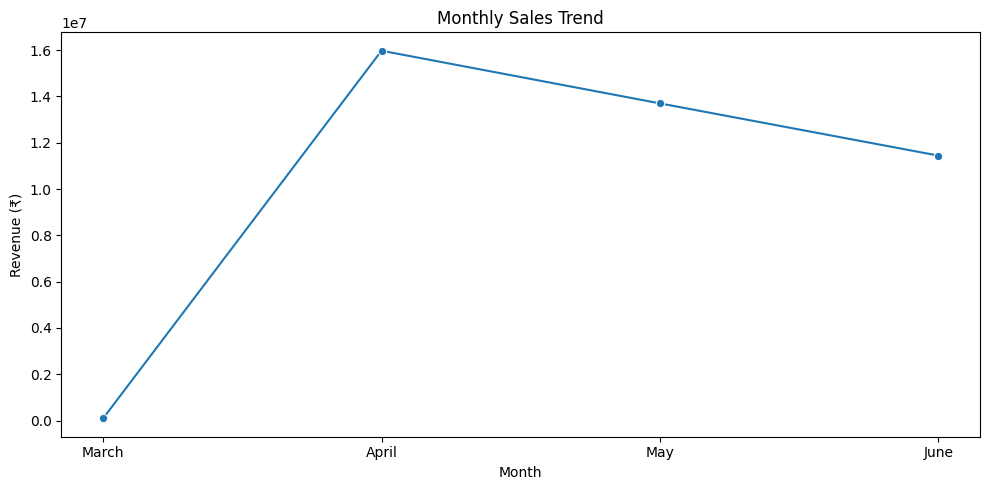

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Revenue', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()

`Weekly Sales Trend`

In [ ]:
weekly_sales = (
    copy_df.groupby('Week', dropna=True).agg(Revenue=('Amount', 'sum'), Orders=('Order ID', 'nunique')).reset_index()
)

display(weekly_sales.head(15).round(2))

,Week,Revenue,Orders
0,13,95355.00,158
1,15,4580579.05,8135
2,16,6484615.00,11320
3,17,4912808.57,8655
4,19,2145009.00,3464
5,20,4800021.00,7755
6,21,5179665.00,8240
7,22,1578457.00,2491
8,24,5063668.00,8291
9,25,4603852.00,7629


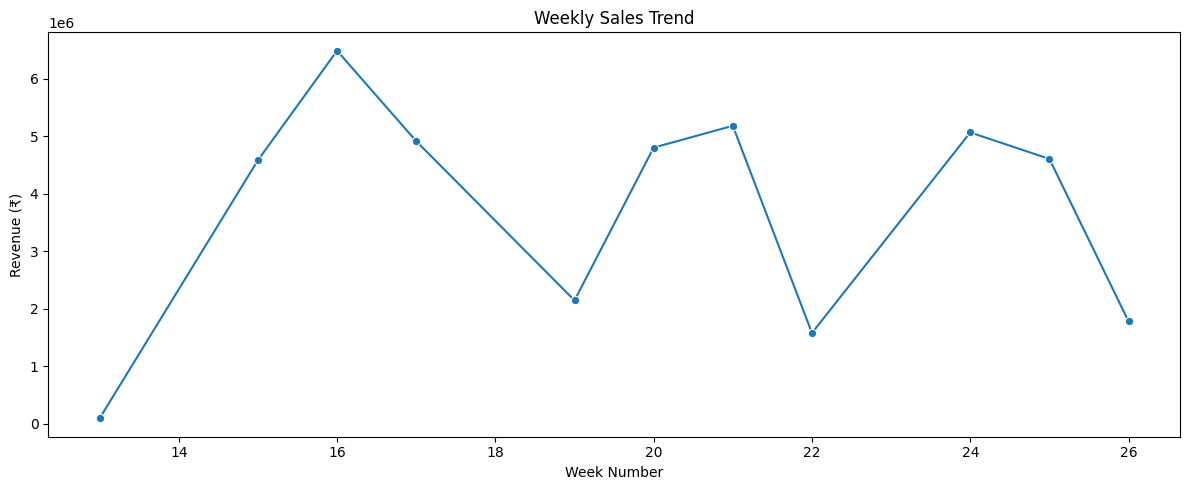

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=weekly_sales, x='Week', y='Revenue', marker='o')
plt.title('Weekly Sales Trend')
plt.xlabel('Week Number')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()


`Sales Trend by Weekday`

In [ ]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
copy_df['Day'] = pd.Categorical(copy_df['Day'], categories=weekday_order, ordered=True)

weekday_sales = (
    copy_df.groupby('Day', observed=True).agg(Revenue=('Amount', 'sum'), Orders=('Order ID', 'nunique')).reset_index()
)

display(weekday_sales.round(2))

,Day,Revenue,Orders
0,Monday,5950671.00,9952
1,Tuesday,6186200.00,10230
2,Wednesday,6004491.00,10014
3,Thursday,5535954.00,9353
4,Friday,5894207.00,9987
5,Saturday,6161595.62,10347
6,Sunday,5491679.00,9033


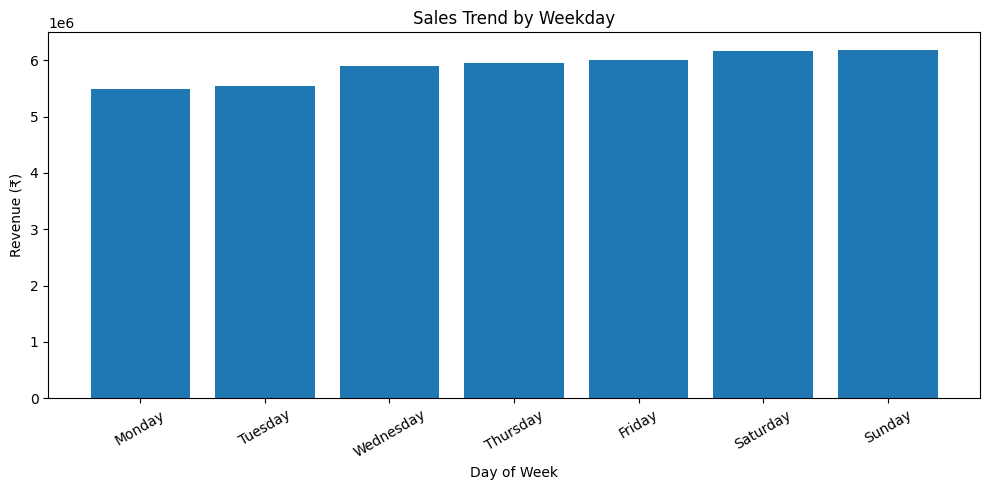

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_sales['Day'].astype(str), weekday_sales['Revenue'].sort_values())
plt.title('Sales Trend by Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

`Revenue by Product Category`

In [ ]:
category_wise_sales = (
    copy_df.groupby('Category')
    .agg(Revenue=('Amount', 'sum'), Quantity=('Qty', 'sum'), Orders=('Order ID', 'nunique')
    ).sort_values('Revenue', ascending=False)
)

display(category_wise_sales.round(2))

,Revenue,Quantity,Orders
Category,,,
Set,35779587.14,45288,47836
kurta,19473807.48,45049,46551
Western Dress,10208405.00,13943,14989
Top,4908912.00,9902,10154
Ethnic Dress,732061.00,1052,1147
Blouse,420569.00,864,897
Bottom,135998.00,398,410
Saree,114694.00,152,144
Dupatta,915.00,3,2


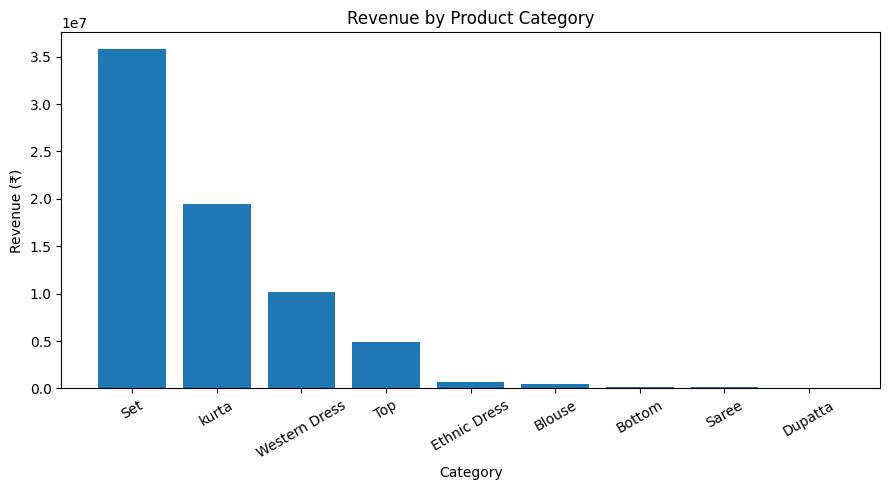

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(category_wise_sales.index.astype(str), category_wise_sales['Revenue'])
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

`Top Product Styles by Revenue`

In [ ]:
top_styles = (
    copy_df.groupby('Style')['Amount'].sum().sort_values(ascending=False).head(10))

display(top_styles.to_frame('Revenue').round(2))

,Revenue
Style,
JNE3797,2637913.0
J0230,1794368.0
SET268,1191886.0
J0341,1153249.0
J0003,880378.0
JNE3405,773811.0
J0008,754504.0
SET345,668756.0
SET278,658413.0


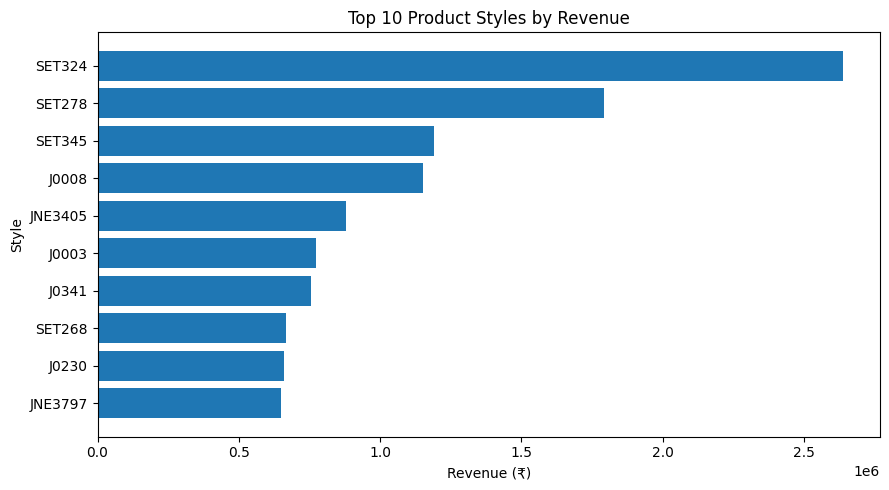

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(top_styles.index.astype(str), top_styles.sort_values())
plt.title('Top 10 Product Styles by Revenue')
plt.xlabel('Revenue (₹)')
plt.ylabel('Style')
plt.tight_layout()
plt.show()

## 5. Product Management & Inventory Analysis

`High demand products`

In [ ]:
display(category_wise_sales.round(2))

,Revenue,Quantity,Orders
Category,,,
Set,35777485.14,45286,47836
kurta,19473274.48,45048,46551
Western Dress,10208405.00,13943,14989
Top,4908912.00,9902,10154
Ethnic Dress,732061.00,1052,1147
Blouse,420569.00,864,897
Bottom,135998.00,398,410
Saree,114694.00,152,144
Dupatta,915.00,3,2


`Average Quantity per Order by Category`


In [ ]:
avg_qty = (copy_df.groupby('Category')['Qty'].mean().sort_values(ascending=False))

display(avg_qty.round(2).to_frame('Average Quantity'))

,Average Quantity
Category,
Dupatta,1.00
Blouse,0.93
Top,0.93
Saree,0.93
Ethnic Dress,0.91
Bottom,0.90
kurta,0.90
Set,0.90
Western Dress,0.90


`Top 10 SKUs by Quantity`

In [ ]:
top_skus = (
    copy_df.groupby('SKU')['Qty'].sum().sort_values(ascending=False).head(10))

display(top_skus.to_frame('Quantity').round(2))

,Quantity
SKU,
JNE3797-KR-L,661
JNE3797-KR-M,561
JNE3797-KR-S,503
JNE3405-KR-L,485
J0230-SKD-M,469
J0230-SKD-S,421
JNE3797-KR-XL,416
JNE3405-KR-S,399
JNE3797-KR-XS,386


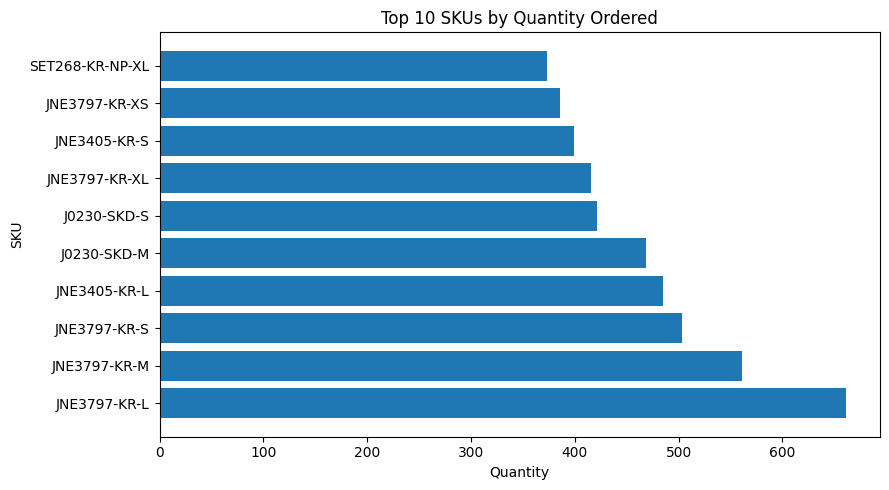

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(top_skus.index.astype(str), top_skus.values)
plt.title('Top 10 SKUs by Quantity Ordered')
plt.xlabel('Quantity')
plt.ylabel('SKU')
plt.tight_layout()
plt.show()

`Size-wise Demand`

In [ ]:
demand = (
    copy_df.groupby('Size')['Qty'].sum().sort_values(ascending=False)
)

display(demand.to_frame('Quantity').round(2))

,Quantity
Size,
M,20449
L,19993
XL,18928
XXL,16511
S,15337
3XL,13525
XS,9939
6XL,688
5XL,513


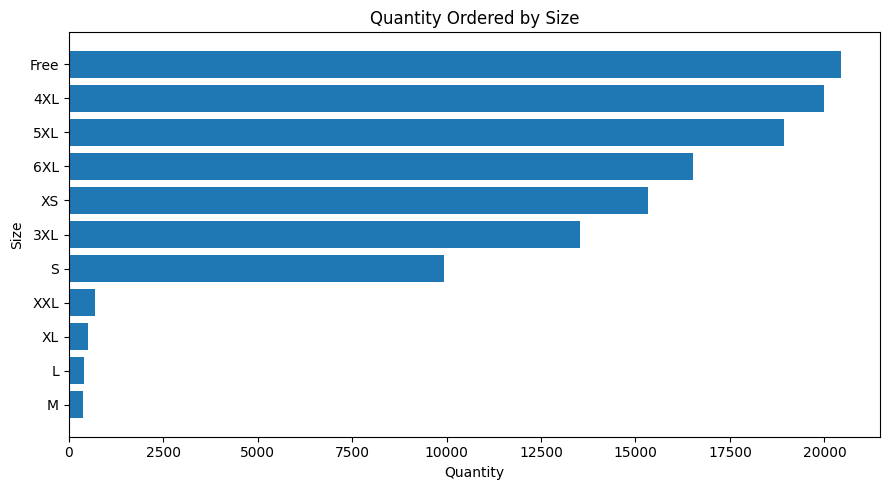

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(demand.index.astype(str), demand.sort_values())
plt.title('Quantity Ordered by Size')
plt.xlabel('Quantity')
plt.ylabel('Size')
plt.tight_layout()
plt.show()

## 6. Customer Satisfaction & Returns

`Order Status Distribution`

In [ ]:
status = copy_df['Status'].value_counts()
display(status.to_frame('Orders'))

,Orders
Status,
Shipped,77767
Shipped - Delivered to Buyer,28771
Cancelled,18341
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


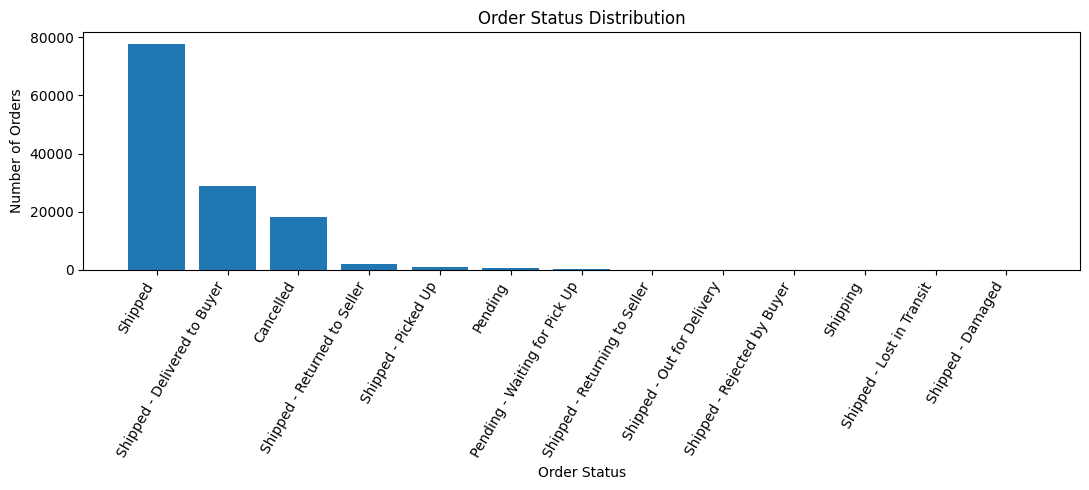

In [ ]:
plt.figure(figsize=(11, 5))
plt.bar(status.index.astype(str), status.values)
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

`Cancellation Rate`

In [ ]:
# Create analysis flags for finding cancellation rate
copy_df['Is_Cancelled'] = copy_df['Status'].eq('Cancelled')
copy_df['Is_Cancelled']

,Is_Cancelled
0,True
1,False
2,False
3,True
4,False
...,...
128944,False
128945,True
128946,False
128947,False


In [ ]:
cancellation_rate = copy_df['Is_Cancelled'].mean() * 100
print(f'Cancellation Rate: {cancellation_rate:.2f}%')

Cancellation Rate: 14.22%


`Return Rate`

In [ ]:
# Create analysis flags for finding Return rate
copy_df['Is_Returned'] = copy_df['Status'].eq('Returned')
copy_df['Is_Returned']

,Is_Returned
0,False
1,False
2,False
3,False
4,False
...,...
128944,False
128945,False
128946,False
128947,False


In [ ]:
return_rate = copy_df['Is_Returned'].mean() * 100
print(f'Return Rate: {return_rate:.2f}%')

Return Rate: 0.00%


`Category-wise Cancellation and Return Rate`



In [ ]:
category_wise = (
    copy_df.groupby('Category').agg(Cancellation_Rate=('Is_Cancelled', 'mean'),
        Return_Rate=('Is_Returned', 'mean')
    )
)

category_wise[['Cancellation_Rate', 'Return_Rate']] *= 100
category_wise = category_wise.sort_values('Cancellation_Rate', ascending=False)

display(category_wise.round(2))

,Cancellation_Rate,Return_Rate
Category,,
Set,14.60,0.0
kurta,14.56,0.0
Western Dress,13.71,0.0
Bottom,13.64,0.0
Saree,12.80,0.0
Ethnic Dress,12.61,0.0
Blouse,12.53,0.0
Top,12.01,0.0
Dupatta,0.00,0.0


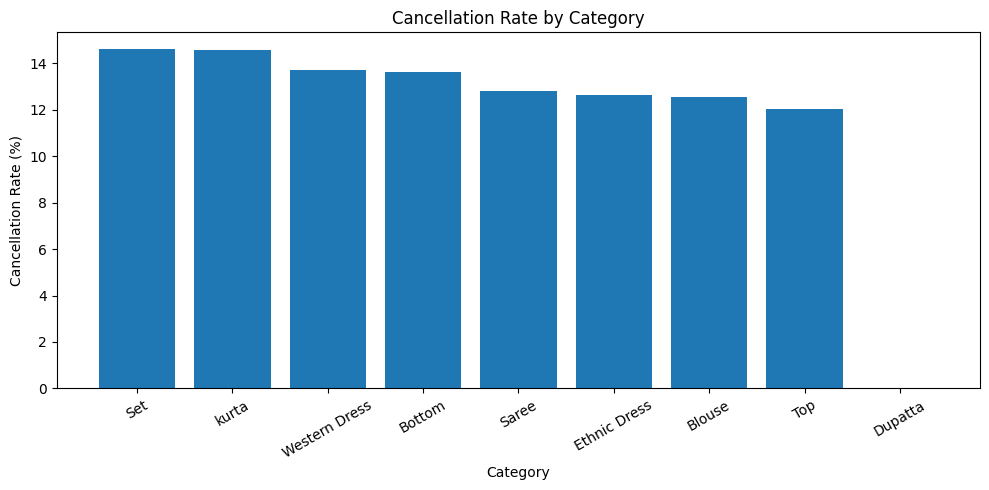

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(category_wise.index.astype(str), category_wise['Cancellation_Rate'])
plt.title('Cancellation Rate by Category')
plt.xlabel('Category')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

>#### Geographical Distribution





In [ ]:
top_states = (
    copy_df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
)

display(top_states.to_frame('Revenue').round(2))

,Revenue
ship-state,
MAHARASHTRA,12234115.00
KARNATAKA,9648329.00
TELANGANA,6293653.57
UTTAR PRADESH,6185048.00
TAMIL NADU,5958817.00
DELHI,3907340.48
KERALA,3378602.00
WEST BENGAL,3208055.00
ANDHRA PRADESH,2886567.00


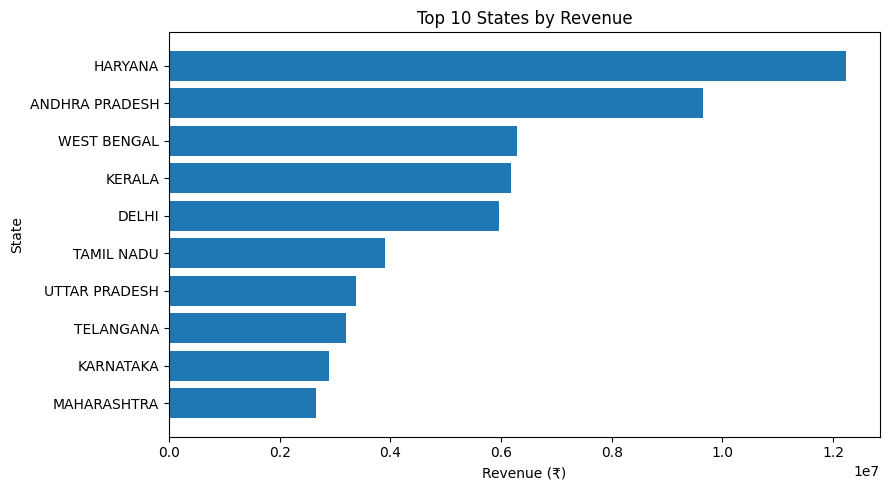

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(top_states.index.astype(str), top_states.sort_values())
plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue (₹)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

`Top Cities by Revenue`

In [ ]:
top_cities = (
    copy_df.groupby('ship-city')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_cities.to_frame('Revenue').round(2))

,Revenue
ship-city,
BENGALURU,6349713.00
HYDERABAD,4499883.57
MUMBAI,3400494.00
NEW DELHI,3331168.48
CHENNAI,2823610.00
PUNE,2154084.00
KOLKATA,1305113.00
GURUGRAM,1135033.00
THANE,918782.00


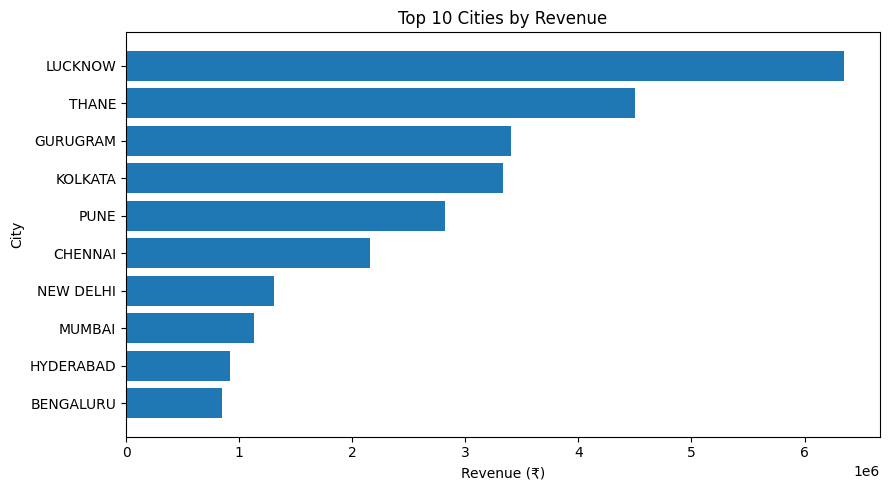

In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(top_cities.index.astype(str), top_cities.sort_values())
plt.title('Top 10 Cities by Revenue')
plt.xlabel('Revenue (₹)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## 7. Customer Insights Analysis

>` B2B vs B2C Revenue and Quantity `

In [ ]:
# Creating a new column from B2B column (0 to B2C and 1 to B2B)
copy_df['Customer_Type'] = np.where(copy_df['B2B'], 'B2B', 'B2C')

copy_df['Customer_Type'].value_counts()


,count
Customer_Type,
B2C,128072
B2B,871


In [ ]:
b2b_summary = (copy_df.groupby('B2B').agg(total_rev=('Amount','sum'), total_qty=('Qty','sum')))
b2b_summary


,total_rev,total_qty
B2B,,
False,71212368.62,115807
True,559945.00,841


In [ ]:
b2b_summary.index = ['B2C' if x is False else 'B2B' for x in b2b_summary.index]
display(b2b_summary.round(2))


,total_rev,total_qty
B2C,71212368.62,115807
B2B,559945.00,841


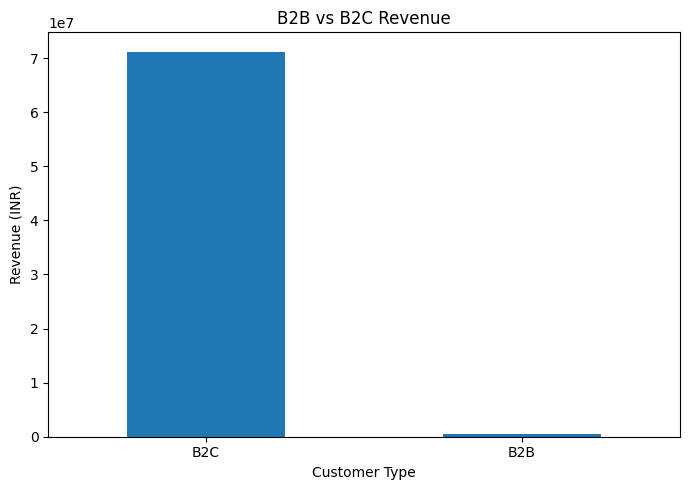

In [ ]:
# Bar graph showing B2B vs B2C Revenue
plt.figure(figsize=(7, 5))
b2b_summary['total_rev'].plot(kind='bar')
plt.title('B2B vs B2C Revenue')
plt.xlabel('Customer Type')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

` Top-performing locations based on sales volume`

In [ ]:
print("Top 5 states by revenue:")
display(top_states.head(5).to_frame('Revenue').round(2))


Top 5 states by revenue:


,Revenue
ship-state,
MAHARASHTRA,12234115.00
KARNATAKA,9648329.00
TELANGANA,6293653.57
UTTAR PRADESH,6185048.00
TAMIL NADU,5958817.00


In [ ]:
print("Top 5 cities by revenue")
display(top_cities.head(5).to_frame('Revenue').round(2))

Top 5 cities by revenue


,Revenue
ship-city,
BENGALURU,6349713.00
HYDERABAD,4499883.57
MUMBAI,3400494.00
NEW DELHI,3331168.48
CHENNAI,2823610.00


##8.  Logistics & Fulfillment Optimization

---



The dataset does not contain actual delivery and shipping dates. Therefore, we cannot calculate average shipping duration.

In [ ]:
# fulfillment comparison
fulfillment_summary = (
    copy_df.groupby('Fulfilment').agg(Orders=('Order ID', 'nunique'),Revenue=('Amount', 'sum'),
        Quantity=('Qty', 'sum')))

fulfillment_summary

,Orders,Revenue,Quantity
Fulfilment,,,
Amazon,83983,50690230.00,84083
Merchant,36369,21082083.62,32565


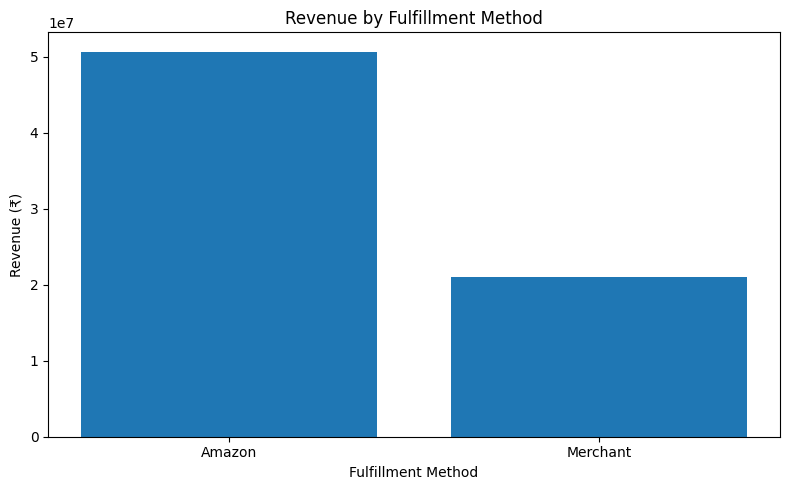

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(fulfillment_summary.index.astype(str), fulfillment_summary['Revenue'])
plt.title('Revenue by Fulfillment Method')
plt.xlabel('Fulfillment Method')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()

`Shipping Service Level Comparison`

In [ ]:
# Shipping service comparison
service_summary = (
    copy_df.groupby('ship-service-level')
    .agg(Orders=('Order ID', 'nunique'),Revenue=('Amount', 'sum'), Quantity=('Qty', 'sum')
    ).sort_values('Revenue', ascending=False)
)

display(service_summary.round(2))

,Orders,Revenue,Quantity
ship-service-level,,,
Expedited,82903,50588589.00,82998
Standard,37449,21183724.62,33650


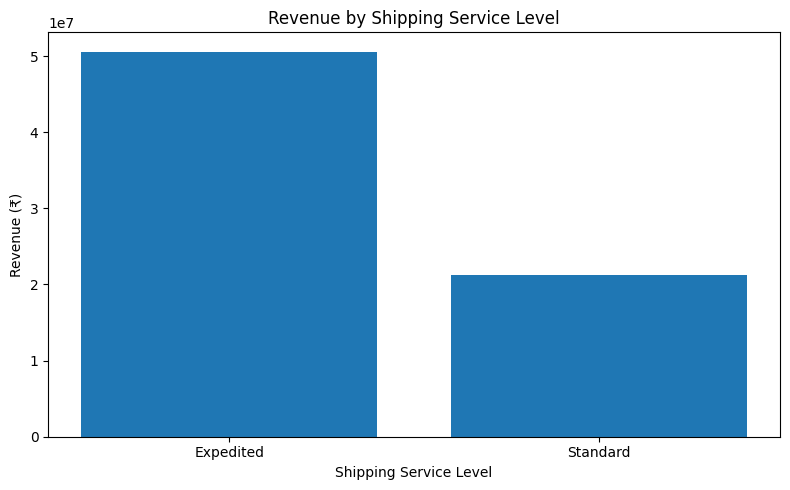

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(service_summary.index.astype(str), service_summary['Revenue'])
plt.title('Revenue by Shipping Service Level')
plt.xlabel('Shipping Service Level')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.show()

`Courier Status Distribution`

In [ ]:
courier_status = copy_df['Courier Status'].value_counts()
display(courier_status.to_frame('Orders'))

,Orders
Courier Status,
Shipped,109460
Unknown,6871
Unshipped,6681
Cancelled,5931


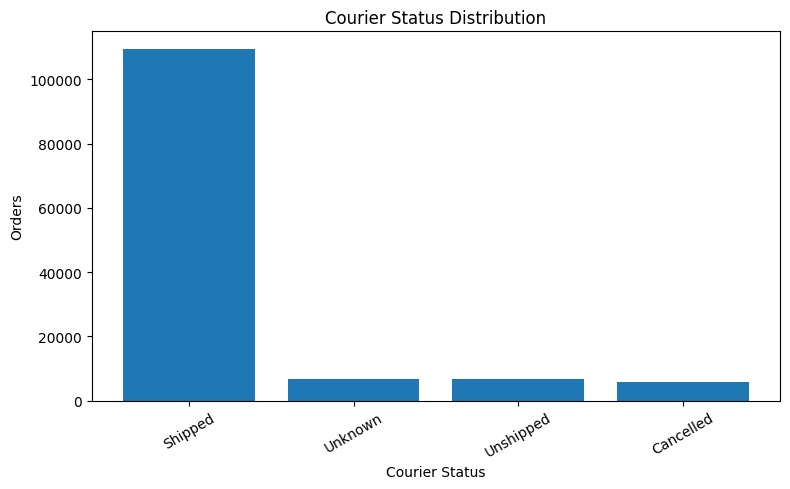

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(courier_status.index.astype(str), courier_status.values)
plt.title('Courier Status Distribution')
plt.xlabel('Courier Status')
plt.ylabel('Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Business Questions and Answers

### Q1. Which product category contributes the most revenue?

In [ ]:
best_rev_category = category_wise_sales['Revenue'].idxmax()
best_rev_value = category_wise_sales['Revenue'].max()
print(f'{best_rev_category} contributes the highest revenue: ₹{best_rev_value:,.2f}')

Set contributes the highest revenue: ₹35,777,485.14


### Q2. Which product styles are the best sellers by revenue?

In [ ]:
print('Top 10 styles by revenue:')
display(top_styles.to_frame('Revenue').round(2))


Top 10 styles by revenue:


,Revenue
Style,
JNE3797,2637913.0
J0230,1793205.0
SET268,1191886.0
J0341,1153249.0
J0003,880378.0
JNE3405,773811.0
J0008,754504.0
SET345,668756.0
SET278,658413.0


### Q3. Which locations have the highest sales?




In [ ]:
print('Top 10 states by revenue:')
display(top_states.to_frame('Revenue').round(2))

print(f'\n------------------------------')

print('Top 10 cities by revenue:')
display(top_cities.to_frame('Revenue').round(2))

Top 10 states by revenue:


,Revenue
ship-state,
MAHARASHTRA,12233176.00
KARNATAKA,9648329.00
TELANGANA,6293653.57
UTTAR PRADESH,6184515.00
TAMIL NADU,5958817.00
DELHI,3907340.48
KERALA,3378602.00
WEST BENGAL,3208055.00
ANDHRA PRADESH,2886567.00



------------------------------
Top 10 cities by revenue:


,Revenue
ship-city,
BENGALURU,6349713.00
HYDERABAD,4499883.57
MUMBAI,3400494.00
NEW DELHI,3331168.48
CHENNAI,2823610.00
PUNE,2153145.00
KOLKATA,1305113.00
GURUGRAM,1135033.00
THANE,918782.00


### Q4. Which fulfillment method performs better?

In [ ]:
display(fulfillment_summary.round(2))

,Orders,Revenue,Quantity
Fulfilment,,,
Amazon,83983,50690230.00,84083
Merchant,36369,21082083.62,32565


In [ ]:
fulfillment_summary.index[0]

'Amazon'

### Q5. Which categories have relatively high return/cancellation rates?

In [ ]:
# Cateogory-> 'Set' has high cancellation rate

print('Categories with highest cancellation rates:')
display(category_wise.sort_values('Cancellation_Rate', ascending=False).round(2))


Categories with highest cancellation rates:


,Cancellation_Rate,Return_Rate
Category,,
Set,14.59,0.0
kurta,14.55,0.0
Western Dress,13.71,0.0
Bottom,13.64,0.0
Saree,12.80,0.0
Ethnic Dress,12.61,0.0
Blouse,12.53,0.0
Top,12.01,0.0
Dupatta,0.00,0.0


In [ ]:
# Category-> 'Western Dress' has high return rate

print('Categories with highest return rates:')
display(category_wise.sort_values('Return_Rate', ascending=False).round(2))


Categories with highest return rates:


,Cancellation_Rate,Return_Rate
Category,,
Set,14.59,0.0
kurta,14.55,0.0
Western Dress,13.71,0.0
Bottom,13.64,0.0
Saree,12.80,0.0
Ethnic Dress,12.61,0.0
Blouse,12.53,0.0
Top,12.01,0.0
Dupatta,0.00,0.0


### Q6. How do B2B and B2C customers differ?

In [ ]:
display(b2b_summary.round(2))

,total_rev,total_qty
B2B,,
False,71212368.62,115807
True,559945.00,841


### Q7. Which are the 10 SKUs need that need special attention?

In [ ]:
top_skus.tail(10).index.tolist()

['JNE3797-KR-L',
 'JNE3797-KR-M',
 'JNE3797-KR-S',
 'JNE3405-KR-L',
 'J0230-SKD-M',
 'J0230-SKD-S',
 'JNE3797-KR-XL',
 'JNE3405-KR-S',
 'JNE3797-KR-XS',
 'SET268-KR-NP-XL']

## 10. Final Conclusion


## Key Insights
Based on the supplied dataset and the cleaning rules:

1. Set is the dominant category by sales value, followed by kurta and Western Dress.

2. The strongest sales concentration is in major states such as Maharashtra, Karnataka, Telangana, Uttar Pradesh and Tamil Nadu.

3. Amazon fulfillment accounts for more orders/revenue and has a lower cancellation rate than Merchant fulfillment in this dataset.

4. B2B orders have a higher average order value than B2C orders, although B2C contributes the overwhelming majority of total revenue because it has far more orders.

##  Business Recommendations
1. Prioritize high-performing categories: Maintain strong inventory availability for Set, kurta and Western Dress because they contribute most of the sales value.

2. Focus on high-value regions: Use targeted marketing and inventory planning in the highest-revenue states.

3. Review processing, inventory availability and dispatch workflows.

4. Use B2B as a growth opportunity: B2B has a higher AOV, so dedicated business offers and account-based marketing may increase revenue per order.

5. Monitor return/cancellation hotspots: Review categories with above-average cancellation or return rates for product quality, sizing, availability and service issues.

6. Improve logistics measurement: Capture order-to-dispatch and dispatch-to-delivery timestamps in future data collection so actual shipping-time KPIs can be calculated.

7. Strengthen customer analytics: Add a customer identifier to enable retention, repeat-purchase and customer lifetime value analysis.

8. Lowest performer SKUs are treated adequetly to enhance inventory control to preven stockouts or overstocking.

## 11. Final Conclusion

The EDA provides a structured view of the e-commerce business, beginning with financial performance and then moving through products, customer satisfaction, geography, customer segments and fulfillment. The analysis connects data-quality checks and business metrics so that recommendations are based on observed patterns rather than unsupported assumptions.

The final recommendations should be updated with the specific values and patterns observed in the outputs after the notebook is executed in Google Colab.